### 04. Model Evaluating

#### Import the Libraries

In [56]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import joblib

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

#### Load the Testing Data and Model

In [57]:
# load testing data
X_test_scaled = np.load('../data/processed/X_test_scaled.npy')
y_test = np.load('../data/processed/y_test.npy')

In [58]:
# load the model
knn = joblib.load('../models/knn_model.pkl')
nb = joblib.load('../models/nb_model.pkl')
rf = joblib.load('../models/rf_model.pkl')

#### Evaluating the Model

In [59]:
# knn
y_pred_knn = knn.predict(X_test_scaled)
print("Akurasi:", accuracy_score(y_test, y_pred_knn))
print("Classification Report:\n", classification_report(y_test, y_pred_knn))

Akurasi: 0.5792682926829268
Classification Report:
               precision    recall  f1-score   support

           0       0.66      0.63      0.65       400
           1       0.46      0.50      0.48       256

    accuracy                           0.58       656
   macro avg       0.56      0.56      0.56       656
weighted avg       0.58      0.58      0.58       656



In [60]:
# naive bayes
y_pred_nb = nb.predict(X_test_scaled)
print("Akurasi:", accuracy_score(y_test, y_pred_nb))
print("Classification Report:\n", classification_report(y_test, y_pred_nb))

Akurasi: 0.5853658536585366
Classification Report:
               precision    recall  f1-score   support

           0       0.66      0.68      0.67       400
           1       0.47      0.45      0.46       256

    accuracy                           0.59       656
   macro avg       0.56      0.56      0.56       656
weighted avg       0.58      0.59      0.58       656



In [61]:
y_pred_rf = rf.predict(X_test_scaled)
print("Akurasi:", accuracy_score(y_test, y_pred_rf))
print("Classification Report:\n", classification_report(y_test, y_pred_rf))

Akurasi: 0.6387195121951219
Classification Report:
               precision    recall  f1-score   support

           0       0.68      0.78      0.72       400
           1       0.55      0.42      0.47       256

    accuracy                           0.64       656
   macro avg       0.61      0.60      0.60       656
weighted avg       0.63      0.64      0.63       656



#### Confusion Matrix

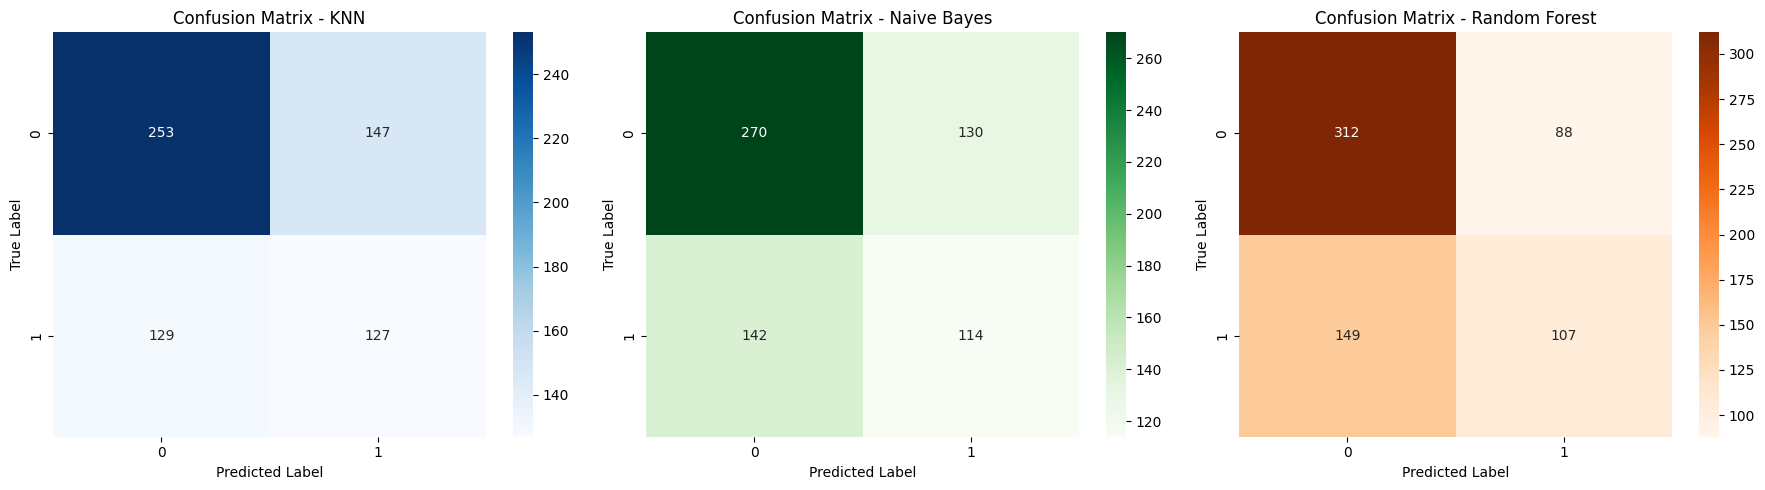

In [62]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Confusion Matrix KNN
sns.heatmap(confusion_matrix(y_test, y_pred_knn), annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Confusion Matrix - KNN')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

# Confusion Matrix Naive Bayes
sns.heatmap(confusion_matrix(y_test, y_pred_nb), annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title('Confusion Matrix - Naive Bayes')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')

# Confusion Matrix Random Forest
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Oranges', ax=axes[2])
axes[2].set_title('Confusion Matrix - Random Forest')
axes[2].set_xlabel('Predicted Label')
axes[2].set_ylabel('True Label')

plt.tight_layout()
plt.show()

#### Comparison of Three Models

In [63]:
model_names = ['KNN', 'Naive Bayes', 'Random Forest']
predictions = [y_pred_knn, y_pred_nb, y_pred_rf]

# focus to class 1
evaluation_metrics = []
for pred in predictions:
    evaluation_metrics.append({
        'Accuracy': round(accuracy_score(y_test, pred), 4),
        'Precision': round(precision_score(y_test, pred), 4),
        'Recall': round(recall_score(y_test, pred), 4),
        'F1-Score': round(f1_score(y_test, pred), 4)
    })

comparison_df = pd.DataFrame(evaluation_metrics, index=model_names)

comparison_df

,Accuracy,Precision,Recall,F1-Score
KNN,0.5793,0.4635,0.4961,0.4792
Naive Bayes,0.5854,0.4672,0.4453,0.4560
Random Forest,0.6387,0.5487,0.4180,0.4745
